<a href="https://colab.research.google.com/github/7amokarim/unet_brain_tumor_segmentation/blob/main/unet_brain_tumor_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload .rar file manually



Saving datasetmy.zip to datasetmy.zip


In [ ]:
import zipfile
import os

zip_path = "datasetmy.zip"
extract_path = "datasetmy"
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")


Extraction done!


In [ ]:
# عرض محتويات المجلد
for root, dirs, files in os.walk("datasetmy/images_masks_txts"):
    print(f"\n📁 Folder: {root}")
    for f in files[:10]:
        print(f"  └── {f}")



📁 Folder: datasetmy/images_masks_txts
  └── 95_jpg.rf.b8e389a4e6e127f06f5adf543ef95557.txt
  └── 2213_jpg.rf.a1d1991b236401463aae3829ec690a99.txt
  └── 1500_jpg.rf.f658701321e99d00b6562520fe0d396e.jpg
  └── 1979_jpg.rf.8218f247dea85333b459c472a8ade4f3_mask.png
  └── 2385_jpg.rf.e5444cc80735be6ae22117d8370bcd87.txt
  └── 2992_jpg.rf.c07ba0f5602a6550a355157cb8efec68_mask.png
  └── 835_jpg.rf.5302548a67d71bda14a8960b3f8c86ed_mask.png
  └── 1130_jpg.rf.e38db23b1c4d880075d9ee9421cb03ee.txt
  └── 286_jpg.rf.9764d664b0c8b452977d377b4fa12ac6.jpg
  └── 747_jpg.rf.c7b73bf5e33e3eedd6e58d1226ee3834_mask.png


## : Load Images and Corresponding Masks

We will load each image and its corresponding mask, resize them to a fixed size (e.g., 128x128), and normalize them.
This will prepare the data for training a U-Net segmentation model.


In [ ]:

print(f"Total images loaded: {len(images)}")
print(f"Total masks loaded: {len(masks)}")

# Show some image and mask names if available
for i in range(5):
    if i < len(images):
        print(f"✅ Image {i} shape: {images[i].shape}, Mask {i} shape: {masks[i].shape}")


Total images loaded: 300
Total masks loaded: 300
✅ Image 0 shape: (128, 128, 3), Mask 0 shape: (128, 128, 1)
✅ Image 1 shape: (128, 128, 3), Mask 1 shape: (128, 128, 1)
✅ Image 2 shape: (128, 128, 3), Mask 2 shape: (128, 128, 1)
✅ Image 3 shape: (128, 128, 3), Mask 3 shape: (128, 128, 1)
✅ Image 4 shape: (128, 128, 3), Mask 4 shape: (128, 128, 1)


In [ ]:
import os
import cv2
import numpy as np

def load_image_mask_pairs(path, img_size=(128, 128)):
    images = []
    masks = []

    for filename in os.listdir(path):
        if "_mask" not in filename and filename.endswith(".jpg"):
            # Paths
            img_path = os.path.join(path, filename)
            mask_filename = filename.replace(".jpg", "_mask.png")
            mask_path = os.path.join(path, mask_filename)

            if os.path.exists(mask_path):
                # Load and resize image
                img = cv2.imread(img_path)
                img = cv2.resize(img, img_size)
                img = img / 255.0  # Normalize

                # Load and resize mask
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, img_size)
                mask = np.expand_dims(mask, axis=-1)
                mask = mask / 255.0  # Normalize

                images.append(img)
                masks.append(mask)

    return np.array(images), np.array(masks)

# ====== Use the function and limit to 300 images ======
dataset_path = "datasetmy/images_masks_txts"

images, masks = load_image_mask_pairs(dataset_path, img_size=(128, 128))

# Use only first 300 image-mask pairs
images = images[:300]
masks = masks[:300]

print(f"✅ Loaded {len(images)} image-mask pairs.")


✅ Loaded 300 image-mask pairs.


In [ ]:
import os

dataset_path = "datasetmy/images_masks_txts"


files = sorted(os.listdir(dataset_path))

print("📂 First 30 files in the dataset folder:\n")
for f in files[:30]:
    print(f)


📂 First 30 files in the dataset folder:

1002_jpg.rf.74495c845455dec52db120e378834be9.jpg
1002_jpg.rf.74495c845455dec52db120e378834be9.txt
1004_jpg.rf.1ef451458c994287cc6a303d1048d017.jpg
1004_jpg.rf.1ef451458c994287cc6a303d1048d017.txt
1004_jpg.rf.1ef451458c994287cc6a303d1048d017_mask.png
1006_jpg.rf.fc1decff7e5c0e9af779c80fbfd26275.jpg
1006_jpg.rf.fc1decff7e5c0e9af779c80fbfd26275.txt
1006_jpg.rf.fc1decff7e5c0e9af779c80fbfd26275_mask.png
1007_jpg.rf.d2ff78395394770c2ea7fd02965bccb1.jpg
1007_jpg.rf.d2ff78395394770c2ea7fd02965bccb1.txt
1007_jpg.rf.d2ff78395394770c2ea7fd02965bccb1_mask.png
1008_jpg.rf.b5c98342f457ce16526ec486f87d3b16.jpg
1008_jpg.rf.b5c98342f457ce16526ec486f87d3b16.txt
1008_jpg.rf.b5c98342f457ce16526ec486f87d3b16_mask.png
1009_jpg.rf.4ddd6ac98adfba1fae9f3234b099c94a.jpg
1009_jpg.rf.4ddd6ac98adfba1fae9f3234b099c94a.txt
1009_jpg.rf.4ddd6ac98adfba1fae9f3234b099c94a_mask.png
1010_jpg.rf.df896073a37cdc3ce18821264e98e2f0.jpg
1010_jpg.rf.df896073a37cdc3ce18821264e98e2f0.txt
101

##  Build the U-Net Model

We will define a basic U-Net architecture using TensorFlow/Keras for semantic segmentation.


In [ ]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bridge
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2, 2))(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2, 2))(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Build the model
unet_model = build_unet(input_shape=(128, 128, 3))
unet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

unet_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_15[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 8, 8, 128) │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 8, 8, 256) │    590,080 │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 384)              │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,962,625 (7.49 MB)

 Trainable params: 1,962,625 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

##  Compile and Train the Model

We will compile the U-Net model using Binary Crossentropy and Adam optimizer, then train it on the image-mask pairs.


from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam


X_train, X_val, y_train, y_val = train_test_split(  test_size=0.1, random_state=42)


unet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])


history = unet_model.fit(X_train, y_train,
                         validation_data=(X_val, y_val),
                         batch_size=8,
                         epochs=20)


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

# تقسيم البيانات لتدريب واختبار
X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.1, random_state=42)

# إعداد الموديل
unet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# تدريب الموديل
history = unet_model.fit(X_train, y_train,
                         validation_data=(X_val, y_val),
                         batch_size=4,
                         epochs=5)



Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 813ms/step - accuracy: 0.9591 - loss: 0.2350 - val_accuracy: 0.9590 - val_loss: 0.1655
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 83s 823ms/step - accuracy: 0.9602 - loss: 0.1501 - val_accuracy: 0.9590 - val_loss: 0.1546
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 55s 812ms/step - accuracy: 0.9622 - loss: 0.1381 - val_accuracy: 0.9590 - val_loss: 0.1514
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 57s 841ms/step - accuracy: 0.9571 - loss: 0.1466 - val_accuracy: 0.9590 - val_loss: 0.1459
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 81s 813ms/step - accuracy: 0.9625 - loss: 0.1310 - val_accuracy: 0.9590 - val_loss: 0.1425


##  Plot Training History

Let's visualize the training and validation loss and accuracy.


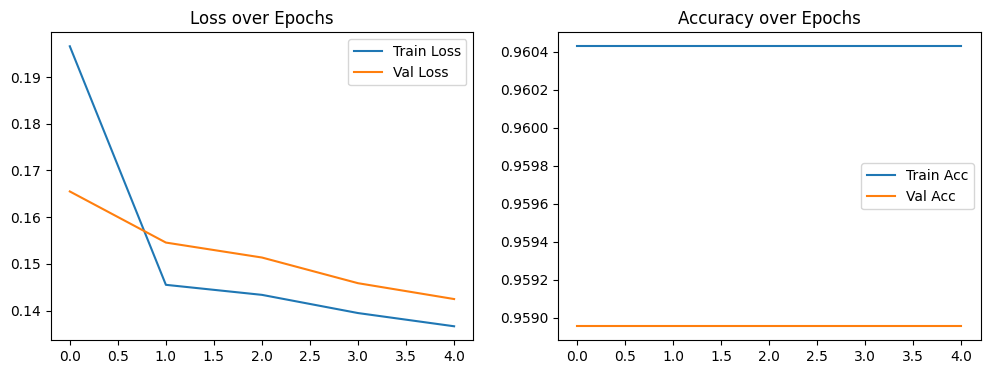

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()


##  Evaluate and Visualize Predictions

We’ll test the model on a few validation images and show the predicted masks.


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_25']
Received: inputs=Tensor(shape=(3, 128, 128, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step


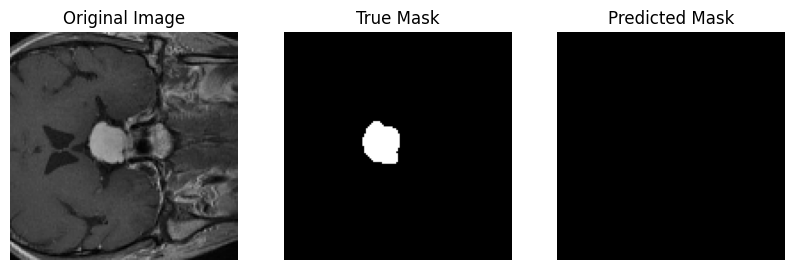

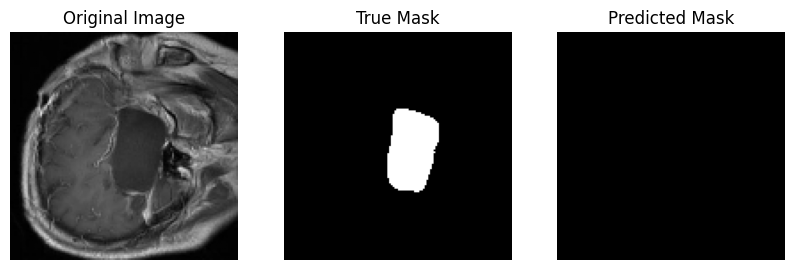

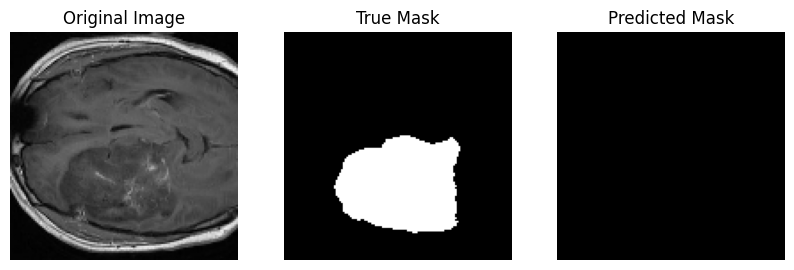

In [ ]:

preds = unet_model.predict(X_val[:3])


for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(X_val[i])
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("True Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.show()


## Step 8: Save the Trained U-Net Model

We will save the model for future use or deployment.


In [ ]:

unet_model.save("unet_segmentation_model.h5")
print("✅ Model saved successfully.")


✅ Model saved successfully.
